### PREPROCESSING & DATA CLEANING - DÉTECTION DE FRAUDE BANCAIRE

**Pipeline complet de préparation des données pour la modélisation**
* **Auditoire :** 3 IDSD ID
* **Date :** Janvier 2026

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from collections import Counter
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

#### 1. CHARGEMENT DES DONNÉES ET EXTRACTION DES 300K LIGNES

In [26]:
try:
    # Charger le fichier complet en DataFrame
    df_full = pd.read_csv('../notebooks/data/fraudTest.csv')
    print(f"✅ Fichier fraudTest.csv chargé avec succès!")
    print(f"   📊 Dimensions totales: {df_full.shape[0]:,} lignes × {df_full.shape[1]} colonnes")
    print(f"   💾 Taille mémoire: {df_full.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
except FileNotFoundError:
    print("❌ Erreur: Le fichier 'fraudTest.csv' n'a pas été trouvé!")
    print("   Veuillez vérifier que le fichier existe dans le répertoire de travail.")
    raise

✅ Fichier fraudTest.csv chargé avec succès!
   📊 Dimensions totales: 555,719 lignes × 23 colonnes
   💾 Taille mémoire: 443.58 MB


In [29]:
# Définir le nombre de lignes à extraire
n_rows = 300000

In [30]:
if len(df_full) >= n_rows:
    df_300k = df_full.head(n_rows).copy()
    print(f"\n✅ Extraction réussie de {n_rows:,} lignes ({(n_rows/len(df_full)*100):.1f}% du total)")
else:
    df_300k = df_full.copy()
    print(f"\n⚠️  Le fichier contient seulement {len(df_full):,} lignes")
    print(f"   Toutes les lignes seront utilisées")
    n_rows = len(df_full)

print(f"📊 Dimensions extraites: {df_300k.shape[0]:,} lignes × {df_300k.shape[1]} colonnes")


✅ Extraction réussie de 300,000 lignes (54.0% du total)
📊 Dimensions extraites: 300,000 lignes × 23 colonnes


In [31]:
# Vérifier que la distribution de la variable cible est maintenue
if 'is_fraud' in df_300k.columns:
    original_fraud_rate = df_full['is_fraud'].mean() * 100
    extracted_fraud_rate = df_300k['is_fraud'].mean() * 100
    print(f"\n   Vérification de la distribution de la fraude:")
    print(f"   • Taux de fraude original: {original_fraud_rate:.3f}%")
    print(f"   • Taux de fraude extrait: {extracted_fraud_rate:.3f}%")
    if abs(original_fraud_rate - extracted_fraud_rate) < 0.1:
        print(f"✅ Distribution similaire maintenue")
    else:
        print(f"⚠️  Différence de distribution: {abs(original_fraud_rate - extracted_fraud_rate):.3f}%")


   Vérification de la distribution de la fraude:
   • Taux de fraude original: 0.386%
   • Taux de fraude extrait: 0.459%
✅ Distribution similaire maintenue


In [32]:
# Libérer la mémoire du DataFrame complet
del df_full
import gc
gc.collect()
print("🗑️  Mémoire libérée (DataFrame original supprimé)")

🗑️  Mémoire libérée (DataFrame original supprimé)


In [33]:
df_300k.to_csv('../notebooks/data/fraudTest.csv', index=False)
print(f"✅ Export réussi!")
print(f"📁 Fichier créé: fraudTest.csv ({n_rows:,} lignes)")
print(f"💾 Taille du fichier: ~{df_300k.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✅ Export réussi!
📁 Fichier créé: fraudTest.csv (300,000 lignes)
💾 Taille du fichier: ~239.46 MB


In [34]:
df = pd.read_csv('../notebooks/data/fraudTest.csv')
print(f"✅ Fichier fraudTest.csv chargé avec succès!")
print(f"📊 Dimensions: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"💾 Utilisation mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✅ Fichier fraudTest.csv chargé avec succès!
📊 Dimensions: 300,000 lignes × 23 colonnes
💾 Utilisation mémoire: 239.46 MB


#### 2. EXPLORATION INITIALE ET IDENTIFICATION DES TYPES DE VARIABLES

In [35]:
# Aperçu des premières lignes
print("="*80)
print("APERÇU DES DONNÉES")
print("="*80)
df.head(80)

APERÇU DES DONNÉES


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,75,2020-06-21 12:38:05,180042946491150,"fraud_Greenholt, O'Hara and Balistreri",shopping_net,4.94,Charles,Robles,M,3337 Lisa Divide,Saint Petersburg,FL,33710,27.7898,-82.7243,341043,"Engineer, land",1989-02-28,7402f469a73cf016d793d3111306017b,1371818285,28.669762,-82.456744,0
76,76,2020-06-21 12:38:22,4149238353975790,fraud_Gottlieb-Hansen,personal_care,74.52,Tanner,Carroll,M,494 Burke Ports,Cokeburg,PA,15324,40.1008,-80.0652,632,Dealer,1989-04-08,069013b8389f4433e2e47ce227ccacf1,1371818302,40.067362,-80.213927,0
77,77,2020-06-21 12:39:10,3583793405872580,"fraud_Douglas, Schneider and Turner",shopping_pos,4.40,Beth,Lambert,F,6447 Johnson Estates Apt. 986,Roosevelt,OK,73564,34.8470,-98.9836,551,Amenity horticulturist,1970-09-27,67d795902f1bdaf4d042abfaa2e37496,1371818350,34.858369,-98.135879,0
78,78,2020-06-21 12:39:25,3575789281659026,"fraud_Gutmann, McLaughlin and Wiza",home,71.68,Lindsay,Wilson,F,7618 Gonzales Mission,Centerview,MO,64019,38.7897,-93.8702,2368,Electronics engineer,1989-07-17,8caf8fcd904f367427bb0f699b8f7453,1371818365,39.485253,-92.983354,0


In [36]:
# Informations sur le dataset
print("\n" + "="*80)
print("INFORMATIONS SUR LES TYPES DE DONNÉES")
print("="*80)
df.info()


INFORMATIONS SUR LES TYPES DE DONNÉES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             300000 non-null  int64  
 1   trans_date_trans_time  300000 non-null  object 
 2   cc_num                 300000 non-null  int64  
 3   merchant               300000 non-null  object 
 4   category               300000 non-null  object 
 5   amt                    300000 non-null  float64
 6   first                  300000 non-null  object 
 7   last                   300000 non-null  object 
 8   gender                 300000 non-null  object 
 9   street                 300000 non-null  object 
 10  city                   300000 non-null  object 
 11  state                  300000 non-null  object 
 12  zip                    300000 non-null  int64  
 13  lat                    300000 non-null  float64
 1

In [37]:
# Statistiques descriptives
print("\n" + "="*80)
print("STATISTIQUES DESCRIPTIVES")
print("="*80)
display(df.describe())


STATISTIQUES DESCRIPTIVES


,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,300000.000000,3.000000e+05,300000.000000,300000.000000,300000.000000,300000.000000,3.000000e+05,3.000000e+05,300000.000000,300000.000000,300000.000000
mean,149999.500000,4.179979e+17,69.548207,48815.774357,38.545185,-90.217189,8.840305e+04,1.376443e+09,38.544460,-90.217166,0.004590
std,86602.684716,1.310088e+18,147.640577,26856.665756,5.066608,13.720143,2.996303e+05,2.783122e+06,5.102371,13.732437,0.067594
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.039532,-166.671575,0.000000
25%,74999.750000,1.800429e+14,9.640000,26237.000000,34.668900,-96.798000,7.410000e+02,1.374066e+09,34.757928,-96.889519,0.000000
50%,149999.500000,3.520550e+15,47.360000,48174.000000,39.371600,-87.476900,2.408000e+03,1.376294e+09,39.381705,-87.435635,0.000000
75%,224999.250000,4.635331e+15,83.090000,72011.000000,41.940400,-80.175200,1.968500e+04,1.378715e+09,41.962497,-80.258575,0.000000
max,299999.000000,4.992346e+18,16837.080000,99783.000000,65.689900,-67.950300,2.906700e+06,1.381587e+09,66.669356,-66.952026,1.000000


In [38]:
# Vérification des valeurs manquantes
print("\n" + "="*80)
print("VALEURS MANQUANTES")
print("="*80)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Colonnes': missing.index,
    'Valeurs_Manquantes': missing.values,
    'Pourcentage': missing_pct.values
})
missing_df = missing_df[missing_df['Valeurs_Manquantes'] > 0]
if len(missing_df) > 0:
    display(missing_df)
else:
    print("✅ Aucune valeur manquante détectée!")


VALEURS MANQUANTES
✅ Aucune valeur manquante détectée!



DISTRIBUTION DE LA VARIABLE CIBLE (is_fraud)
Non-fraude (0): 298,623 (99.54%)
Fraude (1): 1,377 (0.46%)


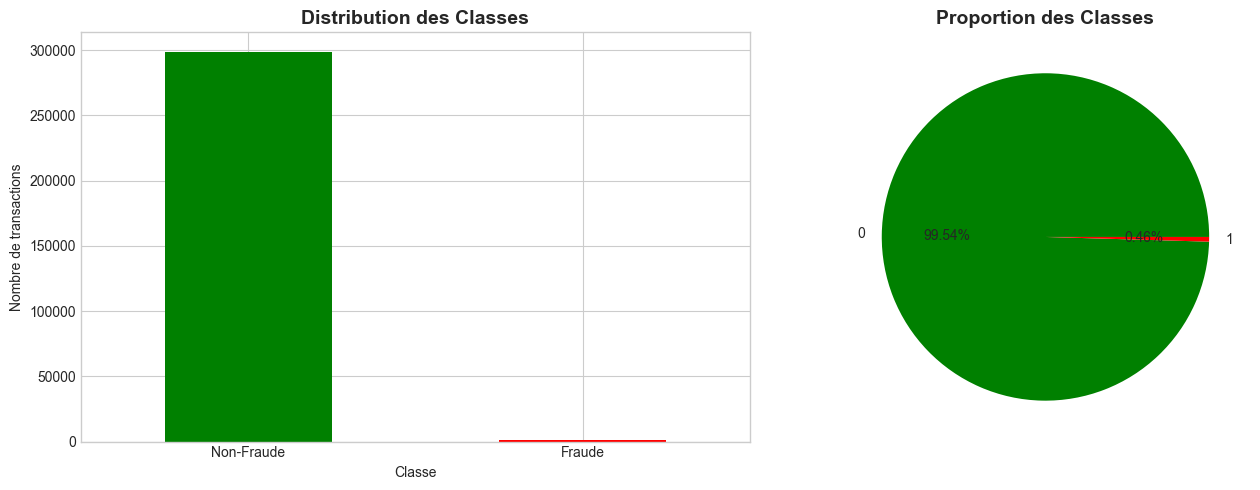

In [40]:
# Distribution de la variable cible
print("\n" + "="*80)
print("DISTRIBUTION DE LA VARIABLE CIBLE (is_fraud)")
print("="*80)
fraud_dist = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

print(f"Non-fraude (0): {fraud_dist[0]:,} ({fraud_pct[0]:.2f}%)")
if 1 in fraud_dist.index:
    print(f"Fraude (1): {fraud_dist[1]:,} ({fraud_pct[1]:.2f}%)")
else:
    print("⚠️ Aucune fraude détectée dans cet échantillon!")

# Visualisation
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df['is_fraud'].value_counts().plot(kind='bar', ax=ax[0], color=['green', 'red'])
ax[0].set_title('Distribution des Classes', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Classe')
ax[0].set_ylabel('Nombre de transactions')
ax[0].set_xticklabels(['Non-Fraude', 'Fraude'], rotation=0)

df['is_fraud'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.2f%%', colors=['green', 'red'])
ax[1].set_title('Proportion des Classes', fontsize=14, fontweight='bold')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

#### 3. NETTOYAGE DES DONNÉES

In [41]:
print("="*80)
print("NETTOYAGE DES DONNÉES")
print("="*80)

# Créer une copie pour le preprocessing
df_clean = df.copy()

# Supprimer la colonne d'index inutile
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop('Unnamed: 0', axis=1)
    print("✓ Colonne 'Unnamed: 0' supprimée")

# Convertir les types de données
df_clean['trans_date_trans_time'] = pd.to_datetime(df_clean['trans_date_trans_time'])
df_clean['dob'] = pd.to_datetime(df_clean['dob'])
print("✓ Dates converties en format datetime")

print(f"\n✓ Dataset nettoyé: {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes")

NETTOYAGE DES DONNÉES
✓ Colonne 'Unnamed: 0' supprimée
✓ Dates converties en format datetime

✓ Dataset nettoyé: 300,000 lignes × 22 colonnes


#### 4. INGÉNIERIE DES FEATURES

In [42]:
print("="*80)
print("INGÉNIERIE DES FEATURES")
print("="*80)

# 4.1 Features temporelles
print("\n📅 Création des features temporelles...")
df_clean['trans_hour'] = df_clean['trans_date_trans_time'].dt.hour
df_clean['trans_day'] = df_clean['trans_date_trans_time'].dt.day
df_clean['trans_month'] = df_clean['trans_date_trans_time'].dt.month
df_clean['trans_year'] = df_clean['trans_date_trans_time'].dt.year
df_clean['trans_dayofweek'] = df_clean['trans_date_trans_time'].dt.dayofweek
df_clean['is_weekend'] = (df_clean['trans_dayofweek'] >= 5).astype(int)
print("   ✓ trans_hour, trans_day, trans_month, trans_year")
print("   ✓ trans_dayofweek, is_weekend")

# 4.2 Âge du client
print("\n👤 Calcul de l'âge...")
df_clean['age'] = (df_clean['trans_date_trans_time'] - df_clean['dob']).dt.days / 365.25
print(f"   ✓ Âge moyen: {df_clean['age'].mean():.1f} ans")

# 4.3 Distance entre client et marchand (formule de Haversine)
print("\n📍 Calcul de la distance client-marchand...")
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Rayon de la Terre en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df_clean['distance_km'] = haversine_distance(
    df_clean['lat'], df_clean['long'],
    df_clean['merch_lat'], df_clean['merch_long']
)
print(f"   ✓ Distance moyenne: {df_clean['distance_km'].mean():.2f} km")

# 4.4 Catégories de montant
print("\n💰 Création des catégories de montant...")
df_clean['amt_category'] = pd.cut(df_clean['amt'], 
                                   bins=[0, 50, 100, 200, float('inf')],
                                   labels=['faible', 'moyen', 'élevé', 'très_élevé'])
print("   ✓ Catégories: faible (<50), moyen (50-100), élevé (100-200), très_élevé (>200)")

# 4.5 Période de la journée
print("\n🕐 Création de la période de la journée...")
def get_period(hour):
    if 6 <= hour < 12:
        return 'matin'
    elif 12 <= hour < 18:
        return 'après-midi'
    elif 18 <= hour < 22:
        return 'soirée'
    else:
        return 'nuit'

df_clean['day_period'] = df_clean['trans_hour'].apply(get_period)
print("   ✓ Périodes: matin, après-midi, soirée, nuit")

print(f"\n✅ Total features: {df_clean.shape[1]} (+ {df_clean.shape[1] - df.shape[1]} nouvelles)")

INGÉNIERIE DES FEATURES

📅 Création des features temporelles...
   ✓ trans_hour, trans_day, trans_month, trans_year
   ✓ trans_dayofweek, is_weekend

👤 Calcul de l'âge...
   ✓ Âge moyen: 46.8 ans

📍 Calcul de la distance client-marchand...
   ✓ Distance moyenne: 76.15 km

💰 Création des catégories de montant...
   ✓ Catégories: faible (<50), moyen (50-100), élevé (100-200), très_élevé (>200)

🕐 Création de la période de la journée...
   ✓ Périodes: matin, après-midi, soirée, nuit

✅ Total features: 32 (+ 9 nouvelles)


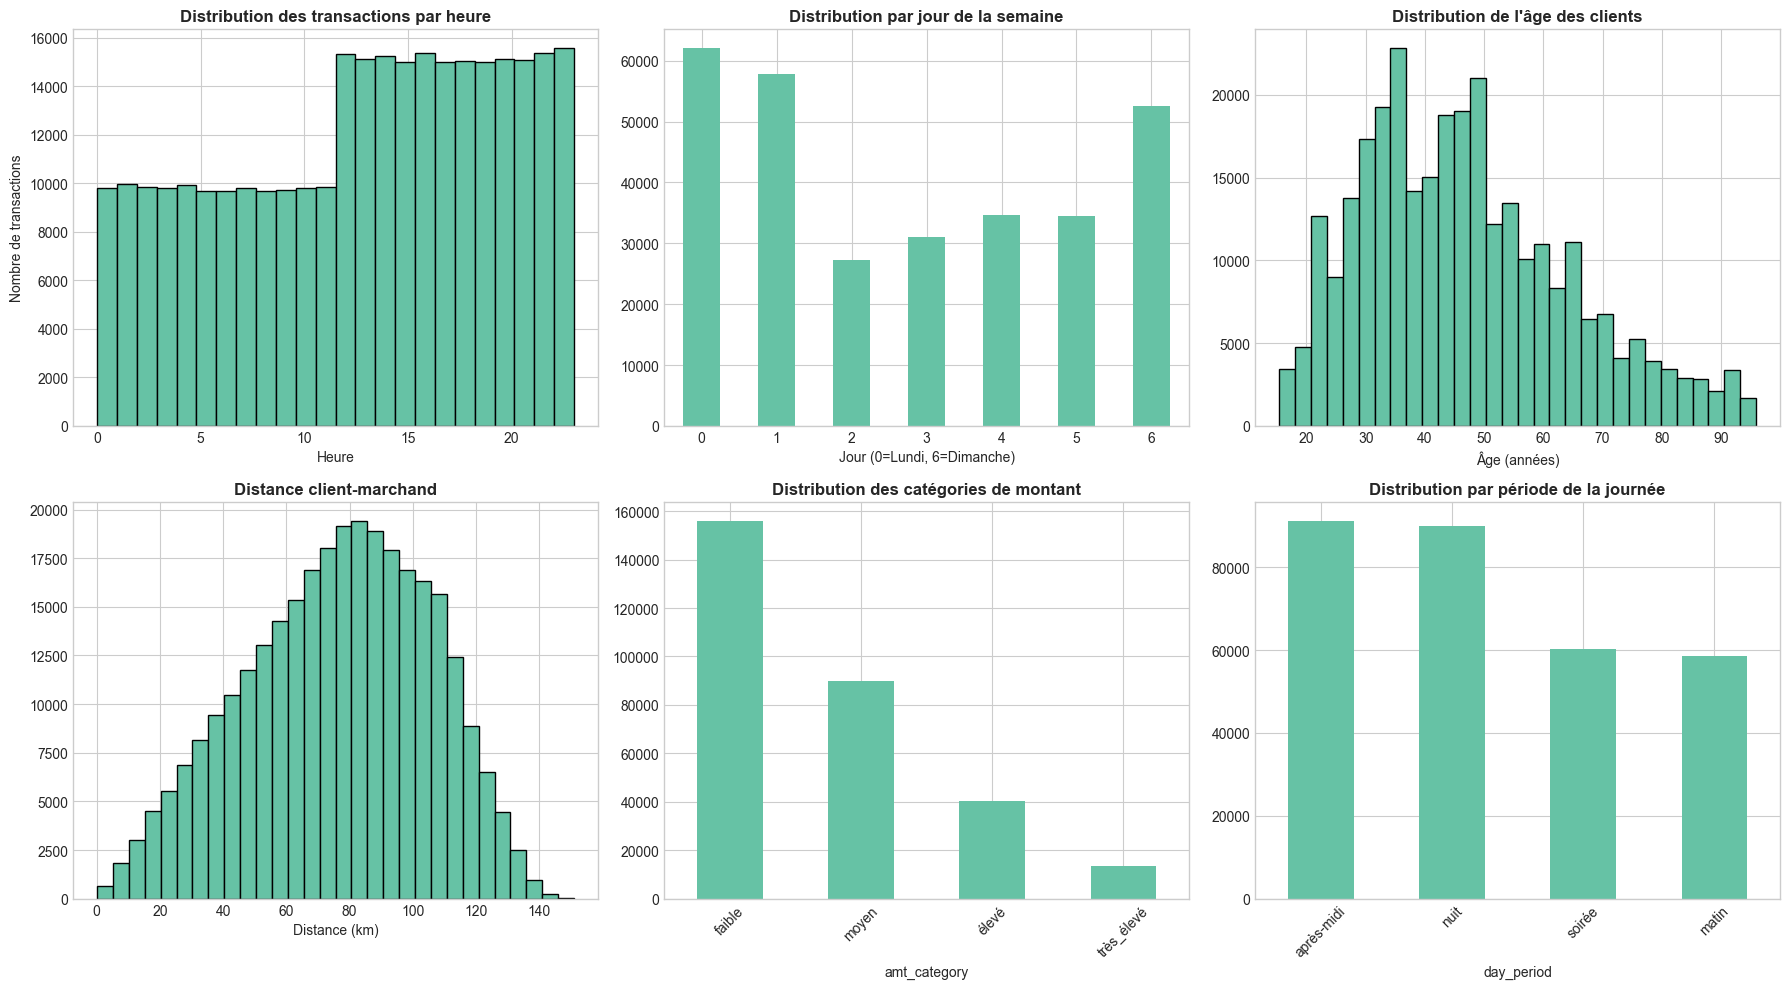

In [43]:
# Visualisation des nouvelles features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Distribution par heure
df_clean['trans_hour'].hist(ax=axes[0,0], bins=24, edgecolor='black')
axes[0,0].set_title('Distribution des transactions par heure', fontweight='bold')
axes[0,0].set_xlabel('Heure')
axes[0,0].set_ylabel('Nombre de transactions')

# Distribution par jour de la semaine
df_clean['trans_dayofweek'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Distribution par jour de la semaine', fontweight='bold')
axes[0,1].set_xlabel('Jour (0=Lundi, 6=Dimanche)')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)

# Distribution de l'âge
df_clean['age'].hist(ax=axes[0,2], bins=30, edgecolor='black')
axes[0,2].set_title('Distribution de l\'âge des clients', fontweight='bold')
axes[0,2].set_xlabel('Âge (années)')

# Distribution de la distance
df_clean['distance_km'].hist(ax=axes[1,0], bins=30, edgecolor='black')
axes[1,0].set_title('Distance client-marchand', fontweight='bold')
axes[1,0].set_xlabel('Distance (km)')

# Catégories de montant
df_clean['amt_category'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Distribution des catégories de montant', fontweight='bold')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45)

# Période de la journée
df_clean['day_period'].value_counts().plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Distribution par période de la journée', fontweight='bold')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

#### 5. SÉLECTION ET PRÉPARATION DES VARIABLES

In [44]:
print("="*80)
print("SÉLECTION DES VARIABLES")
print("="*80)

# Colonnes à supprimer (identifiants, dates, adresses textuelles)
cols_to_drop = [
    'trans_date_trans_time', 'cc_num', 'merchant', 'first', 'last',
    'street', 'trans_num', 'dob', 'unix_time', 'city'
]

# Variables catégorielles à encoder
categorical_features = ['category', 'gender', 'state', 'job', 'amt_category', 'day_period']

# Variables numériques à normaliser
numerical_features = [
    'amt', 'zip', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long',
    'trans_hour', 'trans_day', 'trans_month', 'trans_year', 'trans_dayofweek',
    'is_weekend', 'age', 'distance_km'
]

# Variable cible
target = 'is_fraud'

# Créer le dataset final
df_model = df_clean.drop(columns=cols_to_drop)
print(f"✓ Colonnes supprimées: {len(cols_to_drop)}")
print(f"✓ Variables catégorielles: {len(categorical_features)}")
print(f"✓ Variables numériques: {len(numerical_features)}")
print(f"\n✓ Dataset final: {df_model.shape[0]:,} lignes × {df_model.shape[1]} colonnes")

SÉLECTION DES VARIABLES
✓ Colonnes supprimées: 10
✓ Variables catégorielles: 6
✓ Variables numériques: 15

✓ Dataset final: 300,000 lignes × 22 colonnes


#### 6. ENCODAGE DES VARIABLES CATÉGORIELLES

In [45]:
print("="*80)
print("ENCODAGE DES VARIABLES CATÉGORIELLES")
print("="*80)

# Dictionnaire pour stocker les encodeurs
label_encoders = {}

for col in categorical_features:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le
        print(f"✓ {col}: {len(le.classes_)} classes encodées")
        
print(f"\n✅ {len(label_encoders)} variables encodées avec succès")

ENCODAGE DES VARIABLES CATÉGORIELLES
✓ category: 14 classes encodées
✓ gender: 2 classes encodées
✓ state: 50 classes encodées
✓ job: 478 classes encodées
✓ amt_category: 4 classes encodées
✓ day_period: 4 classes encodées

✅ 6 variables encodées avec succès


#### 7. SÉPARATION FEATURES / TARGET

In [46]:
print("="*80)
print("SÉPARATION DES DONNÉES")
print("="*80)

X = df_model.drop(target, axis=1)
y = df_model[target]

print(f"✓ Features (X): {X.shape}")
print(f"✓ Target (y): {y.shape}")
print(f"✓ Taux de fraude: {y.mean()*100:.2f}%")
print(f"\n📋 Liste des features:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

SÉPARATION DES DONNÉES
✓ Features (X): (300000, 21)
✓ Target (y): (300000,)
✓ Taux de fraude: 0.46%

📋 Liste des features:
    1. category
    2. amt
    3. gender
    4. state
    5. zip
    6. lat
    7. long
    8. city_pop
    9. job
   10. merch_lat
   11. merch_long
   12. trans_hour
   13. trans_day
   14. trans_month
   15. trans_year
   16. trans_dayofweek
   17. is_weekend
   18. age
   19. distance_km
   20. amt_category
   21. day_period


#### 8. TRAIN/TEST SPLIT

In [48]:
from sklearn.model_selection import train_test_split

print("="*80)
print("SÉPARATION TRAIN/TEST")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if y.sum() > 0 else None
)

print(f"\n✓ Train set: {X_train.shape[0]} échantillons ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"✓ Test set: {X_test.shape[0]} échantillons ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n📊 Distribution dans train set:")
print(f"   Non-fraude: {(y_train == 0).sum():,}")
print(f"   Fraude: {(y_train == 1).sum():,}")
print(f"\n📊 Distribution dans test set:")
print(f"   Non-fraude: {(y_test == 0).sum():,}")
print(f"   Fraude: {(y_test == 1).sum():,}")

SÉPARATION TRAIN/TEST

✓ Train set: 240000 échantillons (80.0%)
✓ Test set: 60000 échantillons (20.0%)

📊 Distribution dans train set:
   Non-fraude: 238,898
   Fraude: 1,102

📊 Distribution dans test set:
   Non-fraude: 59,725
   Fraude: 275


#### 9. NORMALISATION DES VARIABLES NUMÉRIQUES

In [50]:
print("="*80)
print("NORMALISATION DES DONNÉES")
print("="*80)

# Utiliser RobustScaler (plus robuste aux outliers)
scaler = RobustScaler()

# Identifier les colonnes numériques dans X_train
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"✓ {len(numeric_cols)} variables numériques normalisées avec RobustScaler")
print(f"\n📊 Exemple de normalisation (5 premières features):")
comparison = pd.DataFrame({
    'Feature': numeric_cols[:5],
    'Mean_avant': [X_train[col].mean() for col in numeric_cols[:5]],
    'Std_avant': [X_train[col].std() for col in numeric_cols[:5]],
    'Mean_après': [X_train_scaled[col].mean() for col in numeric_cols[:5]],
    'Std_après': [X_train_scaled[col].std() for col in numeric_cols[:5]]
})
display(comparison)

NORMALISATION DES DONNÉES
✓ 21 variables numériques normalisées avec RobustScaler

📊 Exemple de normalisation (5 premières features):


,Feature,Mean_avant,Std_avant,Mean_après,Std_après
0,category,6.230417,3.914131,0.032917,0.559162
1,amt,69.379643,145.526150,0.300131,1.982645
2,gender,0.452000,0.497692,0.452000,0.497692
3,state,25.750450,14.119303,-0.010850,0.613883
4,zip,48859.652333,26867.343444,0.014564,0.586956


#### 10. GESTION DU DÉSÉQUILIBRE DES CLASSES (SMOTE)

In [51]:
print("="*80)
print("GESTION DU DÉSÉQUILIBRE DES CLASSES")
print("="*80)

print(f"\n📊 Distribution AVANT SMOTE:")
print(f"  Classe 0 (Non-fraude): {Counter(y_train)[0]:,}")
if 1 in Counter(y_train):
    print(f"  Classe 1 (Fraude): {Counter(y_train)[1]:,}")
    print(f"  Ratio: {Counter(y_train)[0]/Counter(y_train)[1]:.2f}:1")
    
    # Appliquer SMOTE seulement s'il y a des cas de fraude
    smote = SMOTE(random_state=42, k_neighbors=min(5, Counter(y_train)[1]-1))
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    
    print(f"\n📊 Distribution APRÈS SMOTE:")
    print(f"  Classe 0 (Non-fraude): {Counter(y_train_resampled)[0]:,}")
    print(f"  Classe 1 (Fraude): {Counter(y_train_resampled)[1]:,}")
    print(f"  Ratio: 1:1 (équilibré)")
    
    smote_applied = True
    print(f"\n✅ SMOTE appliqué avec succès!")
    print(f"   Échantillons synthétiques créés: {len(X_train_resampled) - len(X_train_scaled):,}")
else:
    print("\n⚠️ Pas de fraude dans le train set - SMOTE non applicable")
    X_train_resampled = X_train_scaled
    y_train_resampled = y_train
    smote_applied = False

GESTION DU DÉSÉQUILIBRE DES CLASSES

📊 Distribution AVANT SMOTE:
  Classe 0 (Non-fraude): 238,898
  Classe 1 (Fraude): 1,102
  Ratio: 216.79:1

📊 Distribution APRÈS SMOTE:
  Classe 0 (Non-fraude): 238,898
  Classe 1 (Fraude): 238,898
  Ratio: 1:1 (équilibré)

✅ SMOTE appliqué avec succès!
   Échantillons synthétiques créés: 237,796


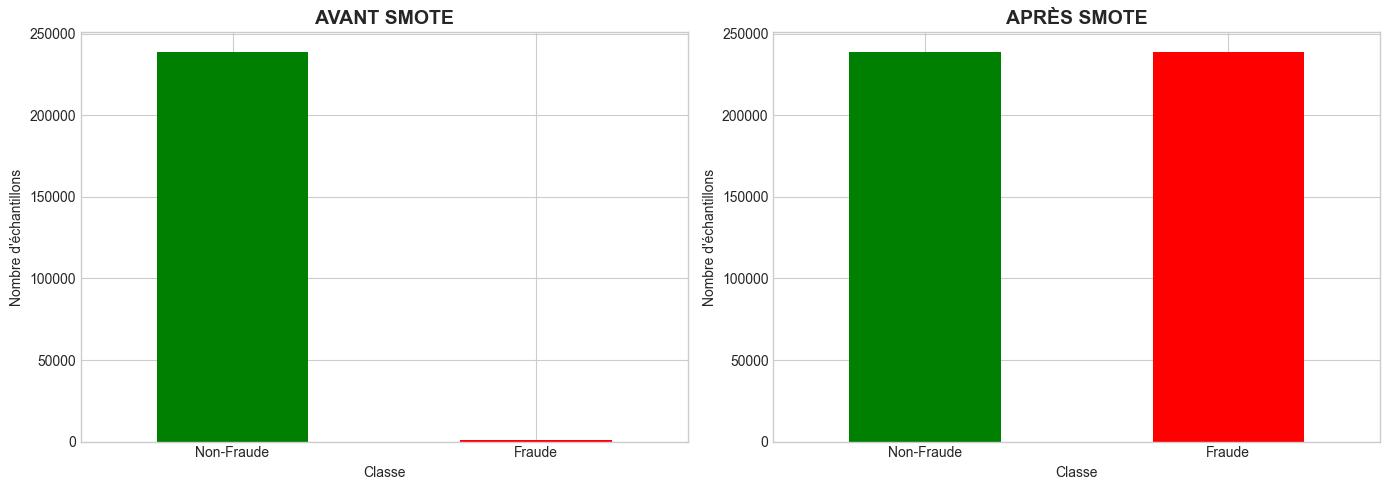

In [52]:
# Visualisation de l'effet de SMOTE
if smote_applied:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Avant SMOTE
    pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
    axes[0].set_title('AVANT SMOTE', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Classe')
    axes[0].set_ylabel('Nombre d\'échantillons')
    axes[0].set_xticklabels(['Non-Fraude', 'Fraude'], rotation=0)
    
    # Après SMOTE
    pd.Series(y_train_resampled).value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red'])
    axes[1].set_title('APRÈS SMOTE', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Classe')
    axes[1].set_ylabel('Nombre d\'échantillons')
    axes[1].set_xticklabels(['Non-Fraude', 'Fraude'], rotation=0)
    
    plt.tight_layout()
    plt.show()

In [53]:
X_train_resampled.head()

,category,amt,gender,state,zip,lat,long,city_pop,job,merch_lat,merch_long,trans_hour,trans_day,trans_month,trans_year,trans_dayofweek,is_weekend,age,distance_km,amt_category,day_period
0,-0.142857,0.729837,0.0,-0.565217,0.267379,0.298778,-0.034910,6.648332,0.836134,0.381947,-0.031924,0.500000,-0.500,0.5,0.0,-0.50,0.0,-0.654479,-0.274235,3.0,0.5
1,-0.571429,0.006812,0.0,0.913043,0.148294,0.686395,-0.098251,0.687183,-0.361345,0.724187,-0.058155,-1.083333,0.875,0.0,0.0,0.75,1.0,1.597244,-0.407431,0.0,0.0
2,0.857143,-0.528338,0.0,0.347826,-0.066479,-0.028399,0.195148,1.530089,-0.071429,-0.087970,0.254433,0.000000,0.375,0.0,0.0,0.50,1.0,-0.851745,0.450907,0.0,-1.0
3,-0.285714,2.389237,0.0,0.000000,-0.426858,-0.454167,0.378925,0.057380,0.500000,-0.321039,0.362011,-0.666667,-0.625,1.0,0.0,-0.50,0.0,-0.494443,0.811622,2.0,-0.5
4,0.571429,-0.340191,0.0,0.652174,-0.224167,-0.474208,0.200255,20.533203,-0.512605,-0.351297,0.214967,0.083333,-0.375,0.5,0.0,0.00,0.0,-0.745721,0.622288,0.0,-1.0


#### 11. SAUVEGARDE DES PROCESSEURS

In [54]:
print("="*80)
print("SAUVEGARDE DES PROCESSEURS")
print("="*80)

# Créer le dossier pour les modèles
os.makedirs('processors', exist_ok=True)

# 1. Sauvegarder le scaler
with open('processors/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler sauvegardé: processors/scaler.pkl")

# 2. Sauvegarder les label encoders
with open('processors/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("✓ Label encoders sauvegardés: processors/label_encoders.pkl")

# 3. Sauvegarder les noms de colonnes
feature_names = {
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'all_features': X.columns.tolist()
}
with open('processors/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
print("✓ Noms des features sauvegardés: processors/feature_names.pkl")

# 4. Sauvegarder SMOTE config
if smote_applied:
    smote_config = {
        'applied': True,
        'strategy': 'SMOTE',
        'random_state': 42
    }
else:
    smote_config = {'applied': False}
    
with open('processors/smote_config.pkl', 'wb') as f:
    pickle.dump(smote_config, f)
print("✓ Configuration SMOTE sauvegardée: processors/smote_config.pkl")

# 5. Sauvegarder les données preprocessées
datasets = {
    'X_train': X_train_resampled,
    'X_test': X_test_scaled,
    'y_train': y_train_resampled,
    'y_test': y_test
}
with open('processors/preprocessed_data.pkl', 'wb') as f:
    pickle.dump(datasets, f)
print("✓ Données preprocessées sauvegardées: processors/preprocessed_data.pkl")

print(f"\n✅ Tous les processeurs ont été sauvegardés dans le dossier 'processors/'")

SAUVEGARDE DES PROCESSEURS
✓ Scaler sauvegardé: processors/scaler.pkl
✓ Label encoders sauvegardés: processors/label_encoders.pkl
✓ Noms des features sauvegardés: processors/feature_names.pkl
✓ Configuration SMOTE sauvegardée: processors/smote_config.pkl
✓ Données preprocessées sauvegardées: processors/preprocessed_data.pkl

✅ Tous les processeurs ont été sauvegardés dans le dossier 'processors/'


#### 12. RÉSUMÉ DU PREPROCESSING

In [55]:
print("="*80)
print("RÉSUMÉ DU PREPROCESSING")
print("="*80)
print(f"""
📊 DONNÉES FINALES:
   • Train set: {X_train_resampled.shape[0]:,} échantillons × {X_train_resampled.shape[1]} features
   • Test set: {X_test_scaled.shape[0]:,} échantillons × {X_test_scaled.shape[1]} features
   • Features totales: {X.shape[1]}
   
🔧 TRANSFORMATIONS APPLIQUÉES:
   • Nettoyage des données
   • Ingénierie de {len(X.columns) - len(df.columns) + len(cols_to_drop)} nouvelles features
   • Encodage de {len(categorical_features)} variables catégorielles
   • Normalisation de {len(numeric_cols)} variables numériques
   • Rééchantillonnage avec SMOTE: {'Oui' if smote_applied else 'Non'}
   
💾 FICHIERS SAUVEGARDÉS:
   • processor/scaler.pkl
   • processor/label_encoders.pkl
   • processor/feature_names.pkl
   • processor/smote_config.pkl
   • processor/preprocessed_data.pkl
   
✅ PREPROCESSING TERMINÉ!
""")

RÉSUMÉ DU PREPROCESSING

📊 DONNÉES FINALES:
   • Train set: 477,796 échantillons × 21 features
   • Test set: 60,000 échantillons × 21 features
   • Features totales: 21

🔧 TRANSFORMATIONS APPLIQUÉES:
   • Nettoyage des données
   • Ingénierie de 8 nouvelles features
   • Encodage de 6 variables catégorielles
   • Normalisation de 21 variables numériques
   • Rééchantillonnage avec SMOTE: Oui

💾 FICHIERS SAUVEGARDÉS:
   • processor/scaler.pkl
   • processor/label_encoders.pkl
   • processor/feature_names.pkl
   • processor/smote_config.pkl
   • processor/preprocessed_data.pkl

✅ PREPROCESSING TERMINÉ!



#### 13. EXEMPLE DE CHARGEMENT DES PROCESSEURS

In [56]:
print("="*80)
print("EXEMPLE DE CHARGEMENT DES PROCESSEURS")
print("="*80)

# Pour charger les processeurs plus tard:

import pickle

# Charger le scaler
with open('processors/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Charger les encoders
with open('processors/label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

# Charger les noms de features
with open('processors/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Charger les données
with open('processors/preprocessed_data.pkl', 'rb') as f:
    datasets = pickle.load(f)
    X_train = datasets['X_train']
    X_test = datasets['X_test']
    y_train = datasets['y_train']
    y_test = datasets['y_test']


print("\n" + "="*80)
print("🎉 NOTEBOOK DE PREPROCESSING TERMINÉ!")
print("="*80)
print("\nProchaines étapes:")
print("  1. Entraîner des modèles de classification")
print("  2. Évaluer les performances")
print("  3. Optimiser les hyperparamètres")
print("  4. Déployer le meilleur modèle")

EXEMPLE DE CHARGEMENT DES PROCESSEURS

🎉 NOTEBOOK DE PREPROCESSING TERMINÉ!

Prochaines étapes:
  1. Entraîner des modèles de classification
  2. Évaluer les performances
  3. Optimiser les hyperparamètres
  4. Déployer le meilleur modèle
